# RetailPulse - Day 9: Churn Prediction (XGBoost + SHAP)
**Week:** 2 | **Day:** 9

---
## Objectives
1. Define what 'churn' means for this dataset (without leaking future information)
2. Engineer features from each customer's PRE-CUTOFF purchase history
3. Create the churn label from POST-CUTOFF behaviour
4. Train/test split (stratified, since churn is usually imbalanced)
5. Train an XGBoost classifier
6. Evaluate: AUC-ROC, Precision@Top20%, Confusion Matrix, Classification Report
7. Feature importance (XGBoost built-in)
8. **SHAP explainability** - global and individual predictions
9. Save the model and results

---
## Why Churn Prediction Matters (Business Context)

From the project spec (F04 - Churn Prediction):
> Classification model to identify at-risk customers.
> Acceptance Criteria: AUC-ROC >= 0.88, precision@top 20% >= 0.75

**Business value:** It is far cheaper to retain an existing customer (discount,
email campaign) than to acquire a new one. If we can identify the customers MOST
likely to stop buying, the marketing team can target them BEFORE they leave.

---
## Why XGBoost?
- Handles tabular data (numbers + categories) extremely well
- Built-in handling of class imbalance (`scale_pos_weight`)
- Fast to train, gives feature importances out of the box
- Works very well with **SHAP** for explainability (tree-based SHAP is exact and fast)

## Why SHAP?
**SHAP (SHapley Additive exPlanations)** explains EACH prediction by showing how
much each feature pushed the prediction up or down compared to the average.
This answers: *'WHY does the model think THIS customer will churn?'* -
essential for a business team to trust and act on the model.


In [4]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================
# If not installed, run in terminal:
#   pip install xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, precision_score,
                              ConfusionMatrixDisplay)
import xgboost as xgb
import shap
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../plots', exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100


print('Libraries imported successfully')
print(f'  XGBoost version : {xgb.__version__}')
print(f'  SHAP version    : {shap.__version__}')


Libraries imported successfully
  XGBoost version : 3.2.0
  SHAP version    : 0.52.0


## Step 1: Define Churn WITHOUT Data Leakage

**The wrong way (data leakage):** Using `Recency` (computed from ALL data, including
the most recent transactions) directly as BOTH a feature AND to define the label
would let the model 'cheat' - it would just learn 'if Recency is high, predict churn',
which is trivially true by construction and tells the business nothing useful.

**The correct way - Time-based split:**
1. Pick a `cutoff_date` somewhere before the end of the dataset (we use 90 days
   before the last transaction).
2. **Features** are computed using ONLY transactions BEFORE `cutoff_date`
   (this is the 'observation window').
3. **Label** is computed using transactions AFTER `cutoff_date` (the 'outcome window'):
   - `churn = 1` if the customer made NO purchase after the cutoff (they 'went silent')
   - `churn = 0` if the customer DID make at least one purchase after the cutoff

This simulates a real production scenario: 'Given everything we know about this
customer up to today, will they buy again in the next 90 days?'


In [5]:
# ============================================================
# CELL 2: LOAD DATA AND DEFINE CUTOFF DATE
# ============================================================

df = pd.read_csv('../data/clean_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

max_date = df['InvoiceDate'].max()
min_date = df['InvoiceDate'].min()

CHURN_WINDOW_DAYS = 90
cutoff_date = max_date - pd.Timedelta(days=CHURN_WINDOW_DAYS)

print(f'Dataset range     : {min_date.date()} to {max_date.date()}')
print(f'Cutoff date        : {cutoff_date.date()}')
print(f'Observation window : {min_date.date()} to {cutoff_date.date()}  '
      f'({(cutoff_date - min_date).days} days)')
print(f'Outcome window     : {cutoff_date.date()} to {max_date.date()}  '
      f'({CHURN_WINDOW_DAYS} days)')

# Split transactions into 'before cutoff' (for features) and 'after cutoff' (for labels)
df_before = df[df['InvoiceDate'] <= cutoff_date].copy()
df_after  = df[df['InvoiceDate'] >  cutoff_date].copy()

print()
print(f'Transactions before cutoff : {len(df_before):,}')
print(f'Transactions after cutoff  : {len(df_after):,}')
print(f'Customers active before cutoff : {df_before["Customer ID"].nunique():,}')
print(f'Customers active after cutoff  : {df_after["Customer ID"].nunique():,}')


Dataset range     : 2009-12-01 to 2011-12-09
Cutoff date        : 2011-09-10
Observation window : 2009-12-01 to 2011-09-10  (648 days)
Outcome window     : 2011-09-10 to 2011-12-09  (90 days)

Transactions before cutoff : 644,022
Transactions after cutoff  : 161,527
Customers active before cutoff : 5,281
Customers active after cutoff  : 2,889


## Step 2: Feature Engineering (from PRE-CUTOFF data only)

For each customer, we compute behavioural features using ONLY transactions up to
the cutoff date:

| Feature | Meaning |
|---------|--------|
| `Recency` | Days between customer's last purchase and the cutoff date |
| `Frequency` | Number of unique orders |
| `Monetary` | Total amount spent |
| `AvgOrderValue` | Monetary / Frequency |
| `Tenure` | Days between first purchase and cutoff date (how long they've been a customer) |
| `AvgDaysBetweenOrders` | Tenure / Frequency (purchase rhythm) |
| `UniqueProducts` | Number of distinct products bought |
| `TotalQuantity` | Total units bought |
| `AvgBasketSize` | TotalQuantity / Frequency |
| `RecencyRatio` | Recency / Tenure (how 'overdue' they are relative to their history) |


In [6]:
# ============================================================
# CELL 3: BUILD FEATURE TABLE (PRE-CUTOFF)
# ============================================================

features = df_before.groupby('Customer ID').agg(
    LastPurchase   = ('InvoiceDate',  'max'),
    FirstPurchase  = ('InvoiceDate',  'min'),
    Frequency      = ('Invoice',      'nunique'),
    Monetary       = ('TotalRevenue', 'sum'),
    UniqueProducts = ('StockCode',    'nunique'),
    TotalQuantity  = ('Quantity',     'sum')
).reset_index()

# Recency = days since last purchase, measured from cutoff date
features['Recency'] = (cutoff_date - features['LastPurchase']).dt.days

# Tenure = how long they've been a customer (first purchase to cutoff)
features['Tenure'] = (cutoff_date - features['FirstPurchase']).dt.days
features['Tenure'] = features['Tenure'].replace(0, 1)  # avoid division by zero

# Derived ratios
features['AvgOrderValue']        = features['Monetary'] / features['Frequency']
features['AvgDaysBetweenOrders'] = features['Tenure'] / features['Frequency']
features['AvgBasketSize']        = features['TotalQuantity'] / features['Frequency']
features['RecencyRatio']         = features['Recency'] / features['Tenure']

# Drop helper date columns (not features for the model)
features = features.drop(columns=['LastPurchase', 'FirstPurchase'])

print(f'Feature table: {len(features):,} customers x {features.shape[1]-1} features')
print()
print(features.head())
print()
print('Feature statistics:')
print(features.describe().round(2))


Feature table: 5,281 customers x 10 features

   Customer ID  Frequency   Monetary  UniqueProducts  TotalQuantity  Recency  \
0        12346         12 77556.4600              27          74285      235   
1        12347          6  4114.1800             107           2418       39   
2        12348          4  1709.4000              25           2497      158   
3        12349          3  2671.1400              90            993      317   
4        12350          1   334.4000              17            197      219   

   Tenure  AvgOrderValue  AvgDaysBetweenOrders  AvgBasketSize  RecencyRatio  
0     635      6463.0383               52.9167      6190.4167        0.3701  
1     313       685.6967               52.1667       403.0000        0.1246  
2     347       427.3500               86.7500       624.2500        0.4553  
3     498       890.3800              166.0000       331.0000        0.6365  
4     219       334.4000              219.0000       197.0000        1.0000  

Feat

Churn label distribution:
----------------------------------------
  Churned (1)    :  2,989 (56.6%)
  Retained (0)   :  2,292 (43.4%)


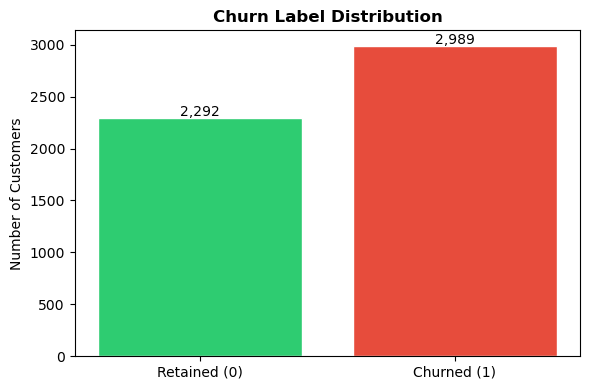


NOTE: This dataset is imbalanced - we will use scale_pos_weight in XGBoost


In [7]:
# ============================================================
# CELL 4: CREATE THE CHURN LABEL (FROM POST-CUTOFF DATA)
# ============================================================

# Customers who made at least one purchase AFTER the cutoff are 'retained' (label=0)
active_after_cutoff = set(df_after['Customer ID'].unique())

features['Churn'] = features['Customer ID'].apply(
    lambda cid: 0 if cid in active_after_cutoff else 1
)

print('Churn label distribution:')
print('-' * 40)
churn_counts = features['Churn'].value_counts()
for label, count in churn_counts.items():
    pct = 100 * count / len(features)
    name = 'Churned (1)' if label == 1 else 'Retained (0)'
    print(f'  {name:<15}: {count:>6,} ({pct:.1f}%)')

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
colors_churn = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Retained (0)', 'Churned (1)'],
              [churn_counts.get(0,0), churn_counts.get(1,0)],
              color=colors_churn, edgecolor='white')
ax.set_title('Churn Label Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{int(bar.get_height()):,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../plots/Day9_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('NOTE: This dataset is imbalanced - we will use scale_pos_weight in XGBoost')


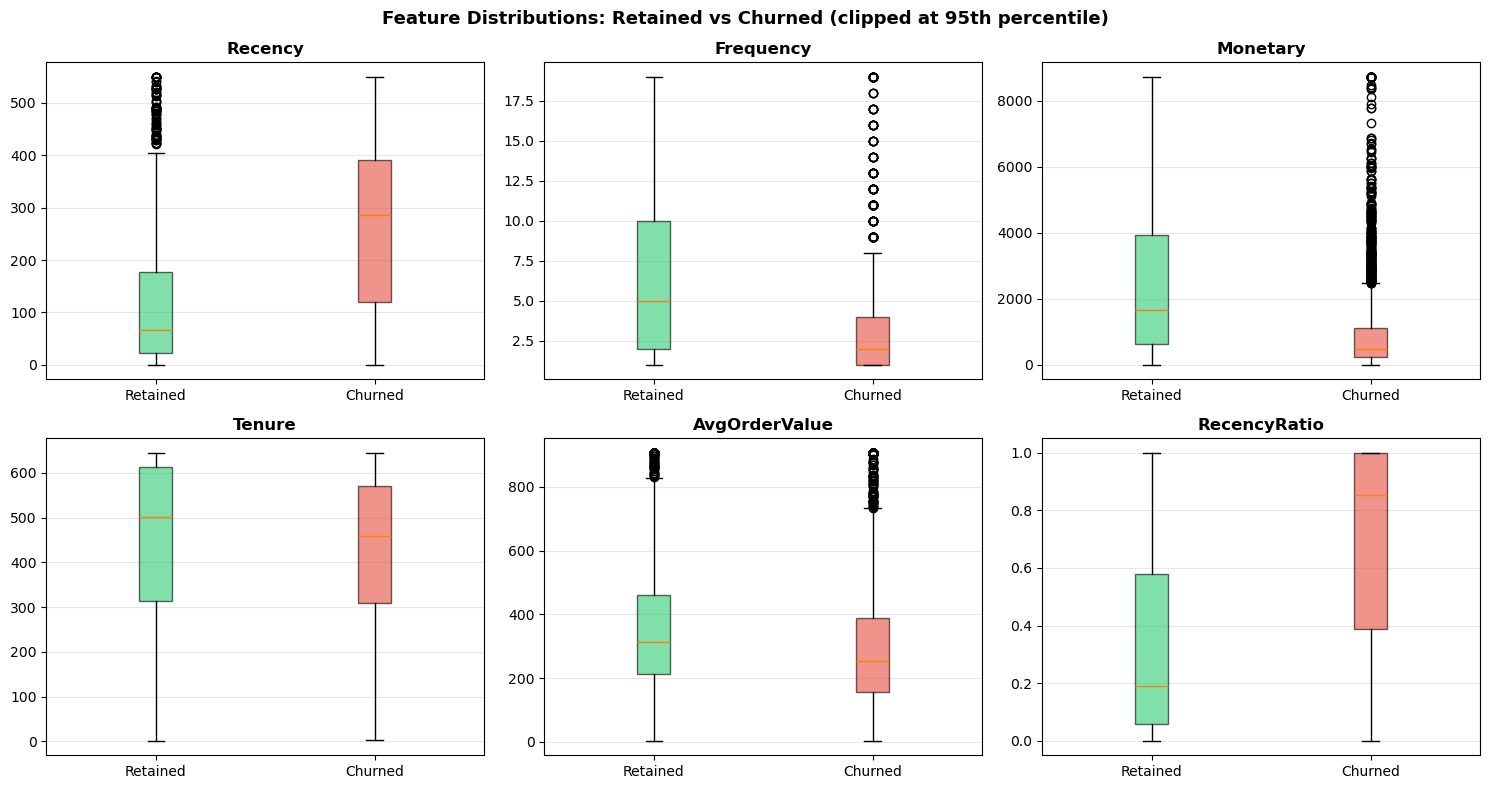

Saved: ../plots/Day9_feature_comparison.png

Expected pattern: Churned customers typically have HIGHER Recency
and HIGHER RecencyRatio (overdue relative to their normal rhythm),
and often LOWER Frequency/Monetary (less engaged historically).


In [8]:
# ============================================================
# CELL 5: EXPLORE FEATURE DIFFERENCES BY CHURN STATUS
# ============================================================

compare_cols = ['Recency', 'Frequency', 'Monetary', 'Tenure',
                'AvgOrderValue', 'RecencyRatio']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    data_to_plot = [
        features[features['Churn']==0][col].clip(upper=features[col].quantile(0.95)),
        features[features['Churn']==1][col].clip(upper=features[col].quantile(0.95))
    ]
    bp = axes[i].boxplot(data_to_plot, labels=['Retained', 'Churned'],
                          patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.6)
    axes[i].set_title(col, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions: Retained vs Churned (clipped at 95th percentile)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day9_feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day9_feature_comparison.png')
print()
print('Expected pattern: Churned customers typically have HIGHER Recency')
print('and HIGHER RecencyRatio (overdue relative to their normal rhythm),')
print('and often LOWER Frequency/Monetary (less engaged historically).')


## Step 3: Train/Test Split

We use a **stratified split** so that both the train and test sets have the
same proportion of churned vs retained customers as the full dataset.
This matters because churn is imbalanced - a random split could accidentally
put too few churned customers in the test set.


In [9]:
# ============================================================
# CELL 6: TRAIN/TEST SPLIT
# ============================================================

feature_cols = ['Recency', 'Frequency', 'Monetary', 'UniqueProducts',
                'TotalQuantity', 'Tenure', 'AvgOrderValue',
                'AvgDaysBetweenOrders', 'AvgBasketSize', 'RecencyRatio']

X = features[feature_cols]
y = features['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} customers')
print(f'Test set     : {X_test.shape[0]:,} customers')
print()
print('Class balance check:')
print(f'  Train - Churn rate: {y_train.mean()*100:.1f}%')
print(f'  Test  - Churn rate: {y_test.mean()*100:.1f}%')
print(f'  Full  - Churn rate: {y.mean()*100:.1f}%')
print()
print('Feature columns used:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i}. {col}')


Training set : 4,224 customers
Test set     : 1,057 customers

Class balance check:
  Train - Churn rate: 56.6%
  Test  - Churn rate: 56.6%
  Full  - Churn rate: 56.6%

Feature columns used:
  1. Recency
  2. Frequency
  3. Monetary
  4. UniqueProducts
  5. TotalQuantity
  6. Tenure
  7. AvgOrderValue
  8. AvgDaysBetweenOrders
  9. AvgBasketSize
  10. RecencyRatio


## Step 4: Train XGBoost Classifier

**Key XGBoost parameters explained:**

| Parameter | Meaning |
|-----------|--------|
| `n_estimators` | Number of trees to build (more trees = more complex model) |
| `max_depth` | Maximum depth of each tree (controls overfitting) |
| `learning_rate` | How much each tree corrects the previous trees' errors |
| `scale_pos_weight` | Up-weights the minority class (churned customers) so the model doesn't ignore them |
| `eval_metric` | Metric used to monitor training (AUC = Area Under ROC Curve) |


In [10]:
# ============================================================
# CELL 7: TRAIN XGBOOST CLASSIFIER
# ============================================================

# scale_pos_weight balances the classes:
# ratio = (number of negative samples) / (number of positive samples)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Retained (neg) in train : {neg_count:,}')
print(f'Churned (pos) in train  : {pos_count:,}')
print(f'scale_pos_weight        : {scale_pos_weight:.3f}')
print()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print('XGBoost training complete!')
print(f'  Trees built: {xgb_model.n_estimators}')


Retained (neg) in train : 1,833
Churned (pos) in train  : 2,391
scale_pos_weight        : 0.767

XGBoost training complete!
  Trees built: 200


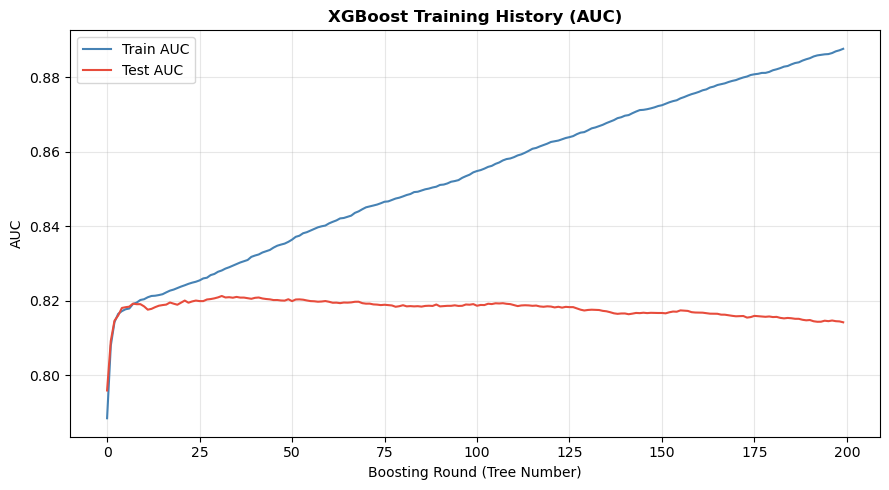

Saved: ../plots/Day9_training_history.png

If Train AUC keeps rising but Test AUC flattens/drops -> overfitting


In [11]:
# ============================================================
# CELL 8: PLOT TRAINING HISTORY (AUC PER ITERATION)
# ============================================================

results_dict = xgb_model.evals_result()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_dict['validation_0']['auc'], label='Train AUC', color='steelblue')
ax.plot(results_dict['validation_1']['auc'], label='Test AUC', color='#e74c3c')
ax.set_title('XGBoost Training History (AUC)', fontsize=12, fontweight='bold')
ax.set_xlabel('Boosting Round (Tree Number)')
ax.set_ylabel('AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/Day9_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day9_training_history.png')
print()
print('If Train AUC keeps rising but Test AUC flattens/drops -> overfitting')


## Step 5: Evaluate the Model

**AUC-ROC (Area Under the ROC Curve):**
- Measures how well the model separates churned vs retained customers across
  ALL possible probability thresholds.
- Range: 0.5 (random guessing) to 1.0 (perfect separation).
- Target from spec: **>= 0.88**

**Precision@Top20%:**
- Sort all customers by predicted churn PROBABILITY (highest first).
- Take the top 20% (the customers the model is MOST confident will churn).
- Precision = what fraction of THOSE customers actually churned?
- This matters because marketing teams have limited budget - they can only
  target a small percentage of customers. We want that small group to be
  highly accurate.
- Target from spec: **>= 0.75**


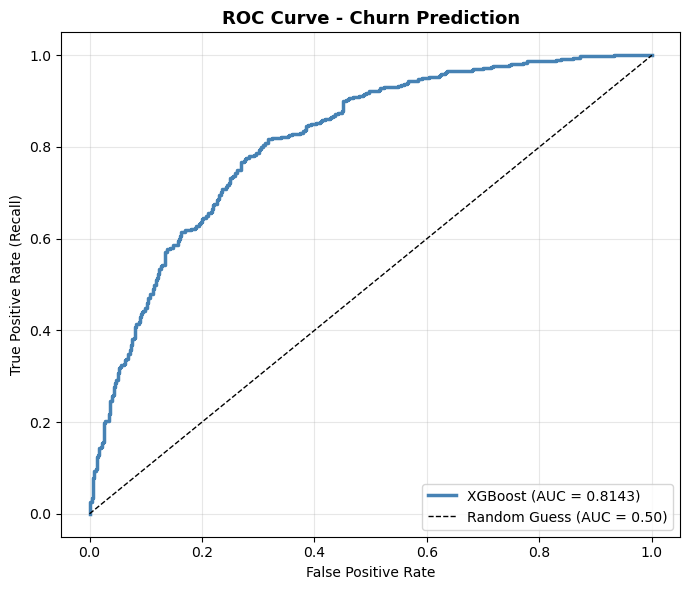

AUC-ROC Score: 0.8143
Target       : >= 0.88
Status       : BELOW TARGET


In [12]:
# ============================================================
# CELL 9: AUC-ROC EVALUATION
# ============================================================

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # probability of churn
y_pred       = xgb_model.predict(X_test)              # hard 0/1 prediction

auc_score = roc_auc_score(y_test, y_pred_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'XGBoost (AUC = {auc_score:.4f})')
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guess (AUC = 0.50)')
ax.set_title('ROC Curve - Churn Prediction', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/Day9_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-ROC Score: {auc_score:.4f}')
print(f'Target       : >= 0.88')
status = 'PASS' if auc_score >= 0.88 else 'BELOW TARGET'
print(f'Status       : {status}')


In [13]:
# ============================================================
# CELL 10: PRECISION@TOP20%
# ============================================================

# Build a results table: actual churn label + predicted probability
eval_df = pd.DataFrame({
    'Customer ID': X_test.index.map(lambda i: features.loc[i, 'Customer ID']),
    'actual': y_test.values,
    'pred_proba': y_pred_proba
})

# Sort by predicted probability, descending (most likely to churn first)
eval_df_sorted = eval_df.sort_values('pred_proba', ascending=False).reset_index(drop=True)

# Top 20% of customers by predicted churn probability
top_20_pct_n = int(len(eval_df_sorted) * 0.20)
top_20 = eval_df_sorted.head(top_20_pct_n)

precision_at_20 = top_20['actual'].mean()  # fraction that ACTUALLY churned

print(f'Test set size               : {len(eval_df_sorted):,} customers')
print(f'Top 20% by predicted risk   : {top_20_pct_n:,} customers')
print(f'Of those, actually churned  : {int(top_20["actual"].sum()):,}')
print(f'Precision@Top20%            : {precision_at_20:.4f}')
print(f'Target                      : >= 0.75')
status20 = 'PASS' if precision_at_20 >= 0.75 else 'BELOW TARGET'
print(f'Status                      : {status20}')
print()
print('Interpretation: If marketing targets these top-20% customers with')
print(f'a retention offer, {precision_at_20*100:.0f}% of them are genuinely at risk -')
print('a much better hit rate than targeting customers randomly.')


Test set size               : 1,057 customers
Top 20% by predicted risk   : 211 customers
Of those, actually churned  : 187
Precision@Top20%            : 0.8863
Target                      : >= 0.75
Status                      : PASS

Interpretation: If marketing targets these top-20% customers with
a retention offer, 89% of them are genuinely at risk -
a much better hit rate than targeting customers randomly.


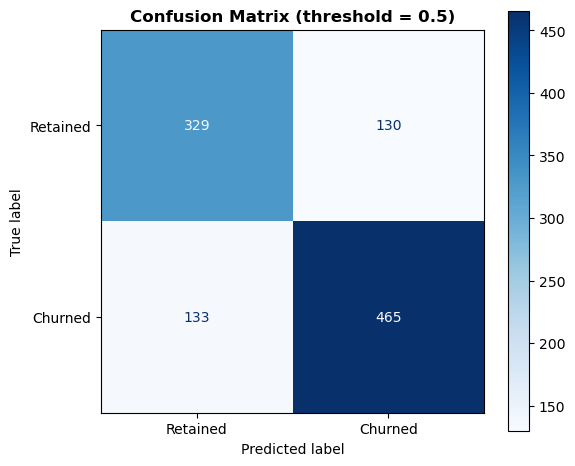

Confusion Matrix breakdown:
  True Negatives  (correctly predicted Retained) : 329
  False Positives (predicted Churn, actually Retained) : 130
  False Negatives (predicted Retained, actually Churned) : 133
  True Positives  (correctly predicted Churn) : 465

Classification Report:
              precision    recall  f1-score   support

    Retained       0.71      0.72      0.71       459
     Churned       0.78      0.78      0.78       598

    accuracy                           0.75      1057
   macro avg       0.75      0.75      0.75      1057
weighted avg       0.75      0.75      0.75      1057



In [14]:
# ============================================================
# CELL 11: CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix (threshold = 0.5)', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day9_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Confusion Matrix breakdown:')
tn, fp, fn, tp = cm.ravel()
print(f'  True Negatives  (correctly predicted Retained) : {tn:,}')
print(f'  False Positives (predicted Churn, actually Retained) : {fp:,}')
print(f'  False Negatives (predicted Retained, actually Churned) : {fn:,}')
print(f'  True Positives  (correctly predicted Churn) : {tp:,}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))


## Step 6: Feature Importance (XGBoost Built-in)

XGBoost's built-in importance shows how often (and how usefully) each feature
was used to split the trees. This gives a GLOBAL view: 'which features matter
most overall?' - but it does NOT tell us the DIRECTION of the effect or how it
affects an individual customer. That's what SHAP gives us next.


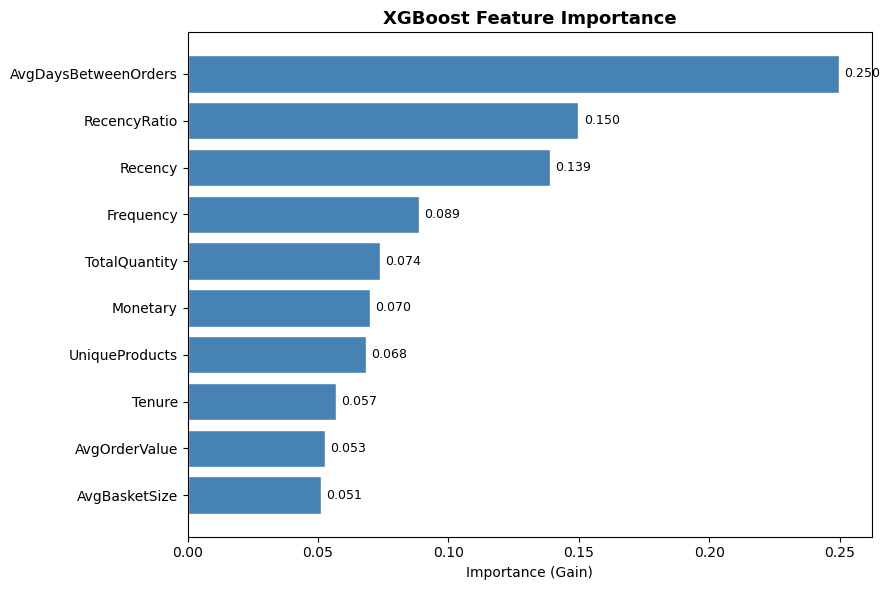

Saved: ../plots/Day9_feature_importance.png

Top 3 most important features:
  AvgDaysBetweenOrders: 0.2498
  RecencyRatio: 0.1498
  Recency: 0.1389


In [15]:
# ============================================================
# CELL 12: XGBOOST BUILT-IN FEATURE IMPORTANCE
# ============================================================

importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance.index, importance.values, color='steelblue', edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gain)')
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../plots/Day9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day9_feature_importance.png')
print()
print('Top 3 most important features:')
for feat, val in importance.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {val:.4f}')


## Step 7: SHAP Explainability

**SHAP values** answer the question: *'For THIS specific customer, how much did
each feature push the prediction towards CHURN (positive SHAP) or RETAIN
(negative SHAP), compared to the average prediction?'*

We use `TreeExplainer`, which is specifically optimized for tree-based models
like XGBoost and gives EXACT (not approximate) SHAP values efficiently.

**Three views we'll create:**
1. **Summary plot** - global view: which features matter most, and in which direction
2. **Dependence plot** - how does ONE feature's value affect the prediction?
3. **Force plot / waterfall** - explain ONE individual customer's prediction


In [16]:
# ============================================================
# CELL 13: COMPUTE SHAP VALUES
# ============================================================

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values computed for {X_test.shape[0]:,} test customers')
print(f'SHAP values shape: {shap_values.shape}  (customers x features)')
print()
print('Each row = one customer.')
print('Each column = one feature.')
print('Value = how much that feature pushed THIS prediction')
print('away from the average prediction (in log-odds space).')


SHAP values computed for 1,057 test customers
SHAP values shape: (1057, 10)  (customers x features)

Each row = one customer.
Each column = one feature.
Value = how much that feature pushed THIS prediction
away from the average prediction (in log-odds space).


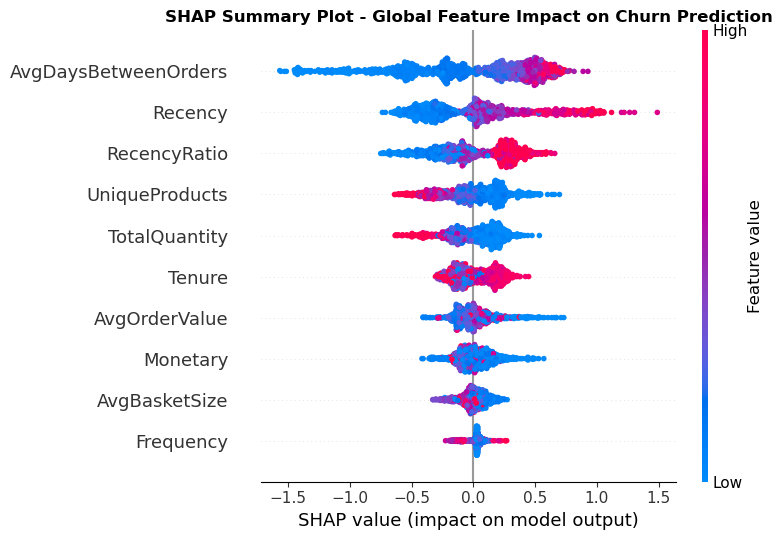

Saved: ../plots/Day9_shap_summary.png

How to read this:
  - High Recency (red dots) on the right -> pushes towards CHURN
  - High Frequency/Monetary (red dots) on the left -> pushes towards RETAIN


In [17]:
# ============================================================
# CELL 14: SHAP SUMMARY PLOT (GLOBAL FEATURE IMPACT)
# ============================================================
# Each dot = one customer.
# Position on x-axis = SHAP value (impact on prediction)
#   Right of center -> pushes towards CHURN
#   Left of center  -> pushes towards RETAIN
# Color = the feature's actual VALUE for that customer (red=high, blue=low)
# Features are sorted by overall importance (top = most important)

fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot - Global Feature Impact on Churn Prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day9_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day9_shap_summary.png')
print()
print('How to read this:')
print('  - High Recency (red dots) on the right -> pushes towards CHURN')
print('  - High Frequency/Monetary (red dots) on the left -> pushes towards RETAIN')


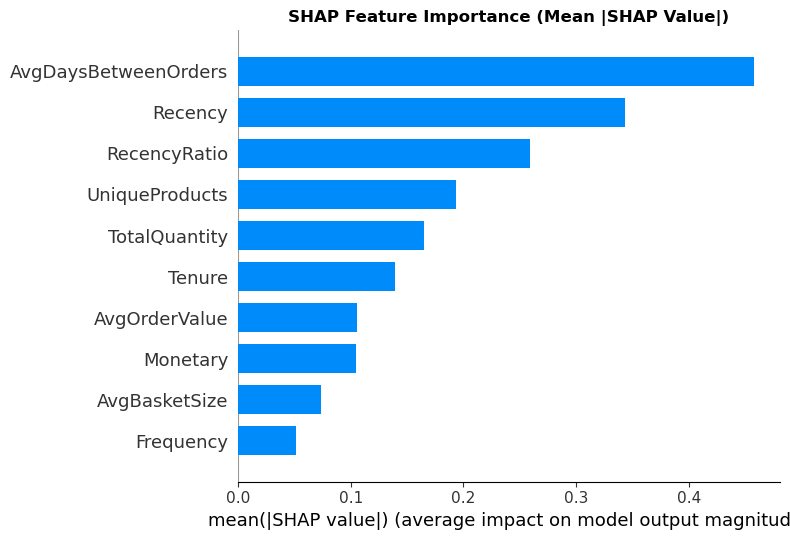

Saved: ../plots/Day9_shap_bar.png


In [18]:
# ============================================================
# CELL 15: SHAP BAR PLOT (MEAN ABSOLUTE IMPACT)
# ============================================================
# This shows the AVERAGE magnitude of each feature's impact,
# regardless of direction. Easier to read than the summary plot
# if you just want a ranking.

fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                   plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day9_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day9_shap_bar.png')


Plotting dependence for top feature: AvgDaysBetweenOrders


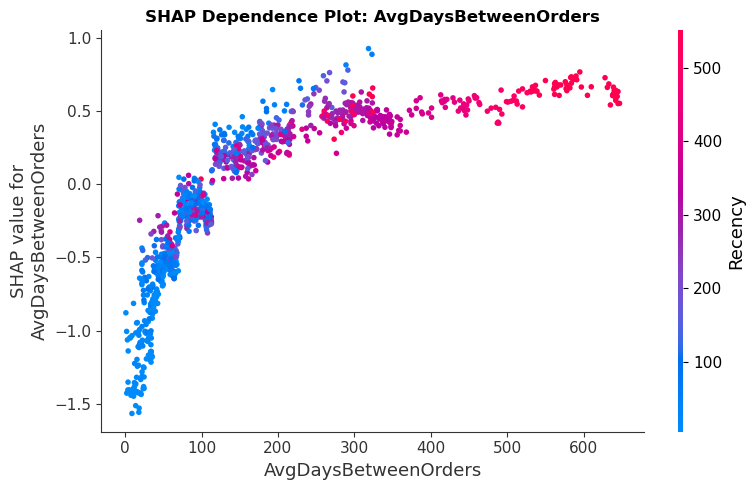

Saved: ../plots/Day9_shap_dependence.png


In [19]:
# ============================================================
# CELL 16: SHAP DEPENDENCE PLOT - TOP FEATURE
# ============================================================
# Shows how the SHAP value (impact on prediction) changes as the
# feature's actual value changes. Reveals non-linear relationships
# that a simple correlation would miss.

top_feature = importance.sort_values(ascending=False).index[0]
print(f'Plotting dependence for top feature: {top_feature}')

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values, X_test,
                      feature_names=feature_cols, ax=ax, show=False)
ax.set_title(f'SHAP Dependence Plot: {top_feature}', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day9_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day9_shap_dependence.png')


Highest-risk customer in test set: 12776.0
Predicted churn probability: 0.9668

Their feature values:
Recency                577.0000
Frequency                1.0000
Monetary                55.5000
UniqueProducts           4.0000
TotalQuantity           46.0000
Tenure                 577.0000
AvgOrderValue           55.5000
AvgDaysBetweenOrders   577.0000
AvgBasketSize           46.0000
RecencyRatio             1.0000
Name: 372, dtype: float64


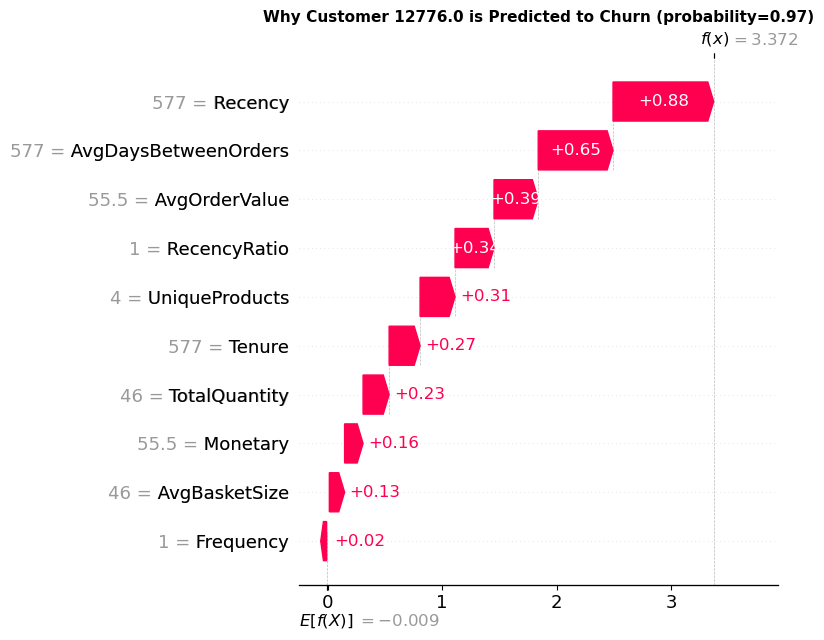

Saved: ../plots/Day9_shap_waterfall.png

Red bars push the prediction TOWARDS churn.
Blue bars push the prediction AWAY from churn (towards retain).


In [20]:
# ============================================================
# CELL 17: SHAP WATERFALL PLOT - EXPLAIN ONE CUSTOMER
# ============================================================
# Pick the customer the model is MOST confident will churn,
# and explain exactly WHY using a waterfall plot.

highest_risk_idx_in_test = np.argmax(y_pred_proba)
highest_risk_customer_id = eval_df.iloc[highest_risk_idx_in_test]['Customer ID']
highest_risk_proba = y_pred_proba[highest_risk_idx_in_test]

print(f'Highest-risk customer in test set: {highest_risk_customer_id}')
print(f'Predicted churn probability: {highest_risk_proba:.4f}')
print()
print('Their feature values:')
print(X_test.iloc[highest_risk_idx_in_test])

# Waterfall plot for this single customer
explanation = shap.Explanation(
    values=shap_values[highest_risk_idx_in_test],
    base_values=explainer.expected_value,
    data=X_test.iloc[highest_risk_idx_in_test].values,
    feature_names=feature_cols
)

fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.title(f'Why Customer {highest_risk_customer_id} is Predicted to Churn '
          f'(probability={highest_risk_proba:.2f})', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day9_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day9_shap_waterfall.png')
print()
print('Red bars push the prediction TOWARDS churn.')
print('Blue bars push the prediction AWAY from churn (towards retain).')


## Step 8: Save the Model and Results

In [21]:
# ============================================================
# CELL 18: SAVE MODEL, FEATURES, AND RESULTS
# ============================================================

import pickle
import json

# Save the trained XGBoost model
with open('../models/churn_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save the full feature table (for use in dashboards / future scoring)
features.to_csv('../data/churn_features.csv', index=False)

# Save evaluation results
eval_df_sorted.to_csv('../data/churn_test_predictions.csv', index=False)

# Save metrics summary
churn_metrics = {
    'model_type': 'XGBoost Churn Classifier',
    'churn_window_days': CHURN_WINDOW_DAYS,
    'cutoff_date': str(cutoff_date.date()),
    'n_customers': len(features),
    'churn_rate': float(y.mean()),
    'auc_roc': float(auc_score),
    'precision_at_top20': float(precision_at_20),
    'feature_columns': feature_cols,
    'scale_pos_weight': float(scale_pos_weight)
}

with open('../models/churn_metrics.json', 'w') as f:
    json.dump(churn_metrics, f, indent=2)

print('Saved:')
print('  ../models/churn_xgboost.pkl       <- trained XGBoost model')
print('  ../models/churn_metrics.json      <- evaluation metrics')
print('  ../data/churn_features.csv        <- full feature table (all customers)')
print('  ../data/churn_test_predictions.csv <- test set predictions')
print()
print('churn_metrics.json contents:')
print(json.dumps(churn_metrics, indent=2))


Saved:
  ../models/churn_xgboost.pkl       <- trained XGBoost model
  ../models/churn_metrics.json      <- evaluation metrics
  ../data/churn_features.csv        <- full feature table (all customers)
  ../data/churn_test_predictions.csv <- test set predictions

churn_metrics.json contents:
{
  "model_type": "XGBoost Churn Classifier",
  "churn_window_days": 90,
  "cutoff_date": "2011-09-10",
  "n_customers": 5281,
  "churn_rate": 0.5659912895284984,
  "auc_roc": 0.8142646876662222,
  "precision_at_top20": 0.8862559241706162,
  "feature_columns": [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "TotalQuantity",
    "Tenure",
    "AvgOrderValue",
    "AvgDaysBetweenOrders",
    "AvgBasketSize",
    "RecencyRatio"
  ],
  "scale_pos_weight": 0.766624843161857
}


In [22]:
# ============================================================
# CELL 19: DAY 9 SUMMARY
# ============================================================

print('=' * 55)
print('  DAY 9 COMPLETE - CHURN PREDICTION MODEL')
print('=' * 55)
print(f'  Total customers analysed : {len(features):,}')
print(f'  Churn rate (full data)   : {y.mean()*100:.1f}%')
print(f'  Train / Test split       : {len(X_train):,} / {len(X_test):,}')
print()
print('  MODEL PERFORMANCE:')
auc_status = 'PASS' if auc_score >= 0.88 else 'BELOW TARGET'
prec_status = 'PASS' if precision_at_20 >= 0.75 else 'BELOW TARGET'
print(f'    AUC-ROC            : {auc_score:.4f}  (target >= 0.88)  [{auc_status}]')
print(f'    Precision@Top20%   : {precision_at_20:.4f}  (target >= 0.75)  [{prec_status}]')
print()
print('  TOP CHURN DRIVERS (by SHAP importance):')
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
for feat, val in shap_importance.sort_values(ascending=False).head(5).items():
    print(f'    {feat}: {val:.4f}')
print()
print('  KEY TAKEAWAYS:')
print('  - Churn label was created using a TIME-BASED split (90-day outcome window)')
print('    to avoid data leakage.')
print('  - scale_pos_weight handles the class imbalance between churned/retained.')
print('  - SHAP explains individual predictions for business stakeholders.')
print()
print('  PLOTS SAVED:')
for p in ['Day9_churn_distribution.png','Day9_feature_comparison.png',
          'Day9_training_history.png','Day9_roc_curve.png',
          'Day9_confusion_matrix.png','Day9_feature_importance.png',
          'Day9_shap_summary.png','Day9_shap_bar.png',
          'Day9_shap_dependence.png','Day9_shap_waterfall.png']:
    print(f'    ../plots/{p}')
print()
print('  Ready for Day 10: Inventory Optimization using Forecasted Demand')
print('=' * 55)


  DAY 9 COMPLETE - CHURN PREDICTION MODEL
  Total customers analysed : 5,281
  Churn rate (full data)   : 56.6%
  Train / Test split       : 4,224 / 1,057

  MODEL PERFORMANCE:
    AUC-ROC            : 0.8143  (target >= 0.88)  [BELOW TARGET]
    Precision@Top20%   : 0.8863  (target >= 0.75)  [PASS]

  TOP CHURN DRIVERS (by SHAP importance):
    AvgDaysBetweenOrders: 0.4579
    Recency: 0.3435
    RecencyRatio: 0.2588
    UniqueProducts: 0.1935
    TotalQuantity: 0.1648

  KEY TAKEAWAYS:
  - Churn label was created using a TIME-BASED split (90-day outcome window)
    to avoid data leakage.
  - scale_pos_weight handles the class imbalance between churned/retained.
  - SHAP explains individual predictions for business stakeholders.

  PLOTS SAVED:
    ../plots/Day9_churn_distribution.png
    ../plots/Day9_feature_comparison.png
    ../plots/Day9_training_history.png
    ../plots/Day9_roc_curve.png
    ../plots/Day9_confusion_matrix.png
    ../plots/Day9_feature_importance.png
    ../plot